# Navigator evaluation with leave-one-path-out cross-validation and class-weighted cross-entropy

This notebook assumes you already extracted the tabular navigator features into a CSV, for example:

- `notebook_outputs/real_nav_lightglue/features_trainable.csv`

Main changes relative to the previous notebook:

1. **Leave-one-path-out cross-validation (LOPO-CV)** at the visual-path level.
2. **Class-weighted cross-entropy** using a small PyTorch MLP.
3. Per-fold and aggregated reporting for:
   - balanced accuracy
   - macro F1
   - weighted F1
   - confusion matrices
   - per-class metrics
4. Dataset audits for:
   - global class imbalance
   - per-path class distribution
   - missing-feature rows

The goal is to evaluate whether the navigator generalizes across visual paths rather than overfitting path-specific bias.


In [1]:
from pathlib import Path
import json
import math
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    balanced_accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_recall_fscore_support,
)
from sklearn.preprocessing import StandardScaler, LabelEncoder

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

warnings.filterwarnings("ignore", category=UserWarning)
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)


## 1. Configuration

Adjust the path if needed.


In [2]:
PROJECT_ROOT = Path.cwd()
# PROJECT_ROOT = Path("/home/rodriguez/Documents/GitHub/rpi_nav")

INPUT_FEATURES_CSV = PROJECT_ROOT / "notebook_outputs" / "real_nav_lightglue" / "features_trainable.csv"
OUTPUT_ROOT = PROJECT_ROOT / "notebook_outputs" / "real_nav_lopo_weighted_ce"
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

FEATURE_COLUMNS = [
    "sim",
    "rmse",
    "x", "y", "z",
    "qw", "qx", "qy", "qz",
]

LABEL_COLUMN = "label_norm"
PATH_COLUMN = "path_name"

# PyTorch MLP
RANDOM_STATE = 42
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
BATCH_SIZE = 64
MAX_EPOCHS = 150
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
HIDDEN_DIMS = [128, 64]
DROPOUT = 0.10
EARLY_STOPPING_PATIENCE = 20

print("DEVICE:", DEVICE)
print("INPUT_FEATURES_CSV:", INPUT_FEATURES_CSV)
print("OUTPUT_ROOT:", OUTPUT_ROOT)


DEVICE: cuda
INPUT_FEATURES_CSV: /home/rodriguez/Documents/GitHub/rpi_nav/notebook_outputs/real_nav_lightglue/features_trainable.csv
OUTPUT_ROOT: /home/rodriguez/Documents/GitHub/rpi_nav/notebook_outputs/real_nav_lopo_weighted_ce


## 2. Reproducibility


In [3]:
def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(RANDOM_STATE)


## 3. Load the extracted features


In [4]:
assert INPUT_FEATURES_CSV.exists(), f"Missing file: {INPUT_FEATURES_CSV}"
df = pd.read_csv(INPUT_FEATURES_CSV)
print("Rows:", len(df))
display(df.head())


Rows: 1642


,path_name,log_row_idx,timestamp_ms,datetime_iso,label,label_norm,simulation_dir,visual_memory_dir,current_rgb_filename,current_depth_filename,key_rgb_filename,key_depth_filename,current_rgb_path,current_depth_path,key_rgb_path,key_depth_path,simulation_dir_exists,visual_memory_dir_exists,current_rgb_exists,current_depth_exists,key_rgb_exists,key_depth_exists,status,fail_reason,sim,bot_lost,rmse,x,y,z,qw,qx,qy,qz
0,Almacen-Laboratorio_J,13,1772083572367,2026-02-25T21:26:12.367120,Update Memory,update memory,/home/rodriguez/Documents/GitHub/rpi_nav/visua...,/home/rodriguez/Documents/GitHub/rpi_nav/visua...,rgb_0013.png,depth_0013.png,rgb_0010.png,depth_0010.png,/home/rodriguez/Documents/GitHub/rpi_nav/visua...,/home/rodriguez/Documents/GitHub/rpi_nav/visua...,/home/rodriguez/Documents/GitHub/rpi_nav/visua...,/home/rodriguez/Documents/GitHub/rpi_nav/visua...,True,True,True,True,True,True,ok,NaN,0.769632,False,0.717583,0.123125,-0.195644,-0.894291,0.998259,-0.012937,0.056632,-0.010197
1,Almacen-Laboratorio_J,30,1772083574443,2026-02-25T21:26:14.443176,Update Memory,update memory,/home/rodriguez/Documents/GitHub/rpi_nav/visua...,/home/rodriguez/Documents/GitHub/rpi_nav/visua...,rgb_0030.png,depth_0030.png,rgb_0013.png,depth_0013.png,/home/rodriguez/Documents/GitHub/rpi_nav/visua...,/home/rodriguez/Documents/GitHub/rpi_nav/visua...,/home/rodriguez/Documents/GitHub/rpi_nav/visua...,/home/rodriguez/Documents/GitHub/rpi_nav/visua...,True,True,True,True,True,True,ok,NaN,0.787968,False,1.219702,-0.068670,-0.666228,-1.772251,0.995320,-0.049125,0.056841,-0.060770
2,Almacen-Laboratorio_J,38,1772083575377,2026-02-25T21:26:15.377475,Forward,forward,/home/rodriguez/Documents/GitHub/rpi_nav/visua...,/home/rodriguez/Documents/GitHub/rpi_nav/visua...,rgb_0038.png,depth_0038.png,rgb_0013.png,depth_0013.png,/home/rodriguez/Documents/GitHub/rpi_nav/visua...,/home/rodriguez/Documents/GitHub/rpi_nav/visua...,/home/rodriguez/Documents/GitHub/rpi_nav/visua...,/home/rodriguez/Documents/GitHub/rpi_nav/visua...,True,True,True,True,True,True,ok,NaN,0.773076,False,1.017799,0.350364,-0.180706,-1.474778,0.999766,-0.002818,0.009392,-0.019282
3,Almacen-Laboratorio_J,39,1772083575507,2026-02-25T21:26:15.507214,Forward,forward,/home/rodriguez/Documents/GitHub/rpi_nav/visua...,/home/rodriguez/Documents/GitHub/rpi_nav/visua...,rgb_0039.png,depth_0039.png,rgb_0013.png,depth_0013.png,/home/rodriguez/Documents/GitHub/rpi_nav/visua...,/home/rodriguez/Documents/GitHub/rpi_nav/visua...,/home/rodriguez/Documents/GitHub/rpi_nav/visua...,/home/rodriguez/Documents/GitHub/rpi_nav/visua...,True,True,True,True,True,True,ok,NaN,0.772637,False,0.807778,0.155365,0.044004,-1.623744,0.999196,0.018878,0.034815,-0.006250
4,Almacen-Laboratorio_J,40,1772083575643,2026-02-25T21:26:15.643184,Forward,forward,/home/rodriguez/Documents/GitHub/rpi_nav/visua...,/home/rodriguez/Documents/GitHub/rpi_nav/visua...,rgb_0040.png,depth_0040.png,rgb_0013.png,depth_0013.png,/home/rodriguez/Documents/GitHub/rpi_nav/visua...,/home/rodriguez/Documents/GitHub/rpi_nav/visua...,/home/rodriguez/Documents/GitHub/rpi_nav/visua...,/home/rodriguez/Documents/GitHub/rpi_nav/visua...,True,True,True,True,True,True,ok,NaN,0.781615,False,0.766848,0.142559,0.031706,-1.613428,0.999161,0.017964,0.036039,-0.007467


## 4. Basic audits


In [5]:
required_cols = [PATH_COLUMN, LABEL_COLUMN] + FEATURE_COLUMNS
missing_required = [c for c in required_cols if c not in df.columns]
assert len(missing_required) == 0, f"Missing columns: {missing_required}"

print("Unique paths:", sorted(df[PATH_COLUMN].dropna().unique().tolist()))
print("Unique labels:", sorted(df[LABEL_COLUMN].dropna().unique().tolist()))

print("\nGlobal label distribution:")
display(
    df[LABEL_COLUMN]
    .value_counts(dropna=False)
    .rename_axis("label")
    .reset_index(name="count")
)

print("\nMissing values in feature columns:")
display(df[FEATURE_COLUMNS].isna().sum().rename_axis("feature").reset_index(name="n_missing"))

valid_df = df.dropna(subset=FEATURE_COLUMNS + [PATH_COLUMN, LABEL_COLUMN]).copy()
print("\nRows after dropping missing feature/label/path values:", len(valid_df))


Unique paths: ['Almacen-Laboratorio_J', 'Cuarto_O-Laboratorio_M', 'Cubiculo_13-Laboratorio_I', 'Cubiculo_3-Laboratorio_E', 'Sala_E-Laboratorio_A']
Unique labels: ['forward', 'left', 'right', 'update memory']

Global label distribution:


,label,count
0,forward,945
1,left,278
2,right,227
3,update memory,192



Missing values in feature columns:


,feature,n_missing
0,sim,0
1,rmse,2
2,x,2
3,y,2
4,z,2
5,qw,2
6,qx,2
7,qy,2
8,qz,2



Rows after dropping missing feature/label/path values: 1640


## 5. Per-path class distribution

This is essential. If some paths barely contain certain classes, a single held-out path can produce misleading conclusions.


label_norm,forward,left,right,update memory
path_name,,,,
Almacen-Laboratorio_J,294,76,76,72
Cuarto_O-Laboratorio_M,152,27,21,31
Cubiculo_13-Laboratorio_I,171,83,39,30
Cubiculo_3-Laboratorio_E,212,52,53,32
Sala_E-Laboratorio_A,116,40,38,25


label_norm,forward,left,right,update memory
path_name,,,,
Almacen-Laboratorio_J,0.568,0.147,0.147,0.139
Cuarto_O-Laboratorio_M,0.658,0.117,0.091,0.134
Cubiculo_13-Laboratorio_I,0.529,0.257,0.121,0.093
Cubiculo_3-Laboratorio_E,0.607,0.149,0.152,0.092
Sala_E-Laboratorio_A,0.530,0.183,0.174,0.114


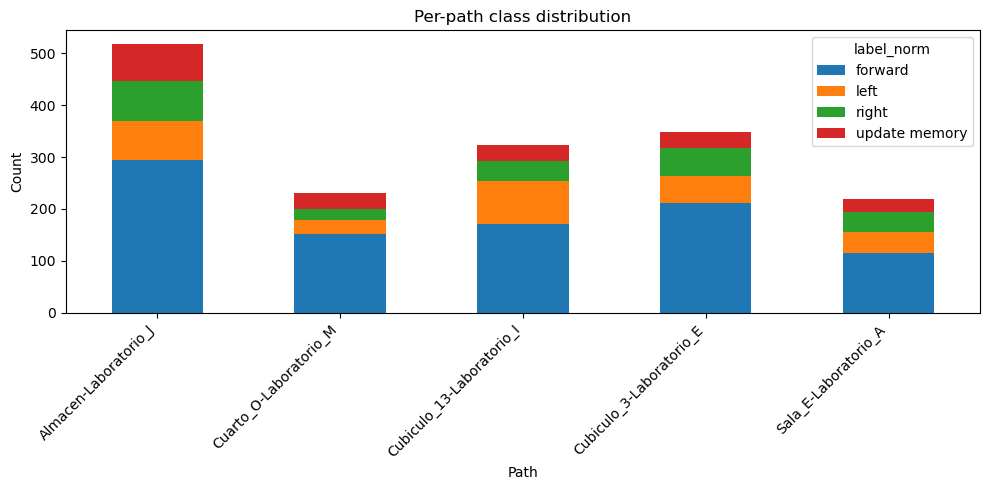

In [6]:
path_label_counts = (
    valid_df.groupby([PATH_COLUMN, LABEL_COLUMN])
    .size()
    .unstack(fill_value=0)
    .sort_index()
)

display(path_label_counts)

path_label_props = path_label_counts.div(path_label_counts.sum(axis=1), axis=0)
display(path_label_props.round(3))

plt.figure(figsize=(10, 5))
path_label_counts.plot(kind="bar", stacked=True, ax=plt.gca())
plt.title("Per-path class distribution")
plt.xlabel("Path")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


## 6. Helper classes and functions


In [7]:
class TabularDataset(Dataset):
    def __init__(self, X: np.ndarray, y: np.ndarray):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


class WeightedMLP(nn.Module):
    def __init__(self, in_dim: int, out_dim: int, hidden_dims=(128, 64), dropout=0.10):
        super().__init__()
        layers = []
        prev = in_dim
        for h in hidden_dims:
            layers.extend([
                nn.Linear(prev, h),
                nn.ReLU(),
                nn.Dropout(dropout),
            ])
            prev = h
        layers.append(nn.Linear(prev, out_dim))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


def compute_class_weights(y_enc: np.ndarray, n_classes: int) -> np.ndarray:
    counts = np.bincount(y_enc, minlength=n_classes).astype(np.float64)
    weights = np.zeros_like(counts)
    nonzero = counts > 0
    weights[nonzero] = len(y_enc) / (n_classes * counts[nonzero])
    return weights


def train_torch_mlp(
    X_train, y_train,
    X_val, y_val,
    n_classes,
    hidden_dims=(128, 64),
    dropout=0.10,
    lr=1e-3,
    weight_decay=1e-4,
    batch_size=64,
    max_epochs=150,
    patience=20,
    device="cpu",
):
    train_ds = TabularDataset(X_train, y_train)
    val_ds = TabularDataset(X_val, y_val)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)

    model = WeightedMLP(
        in_dim=X_train.shape[1],
        out_dim=n_classes,
        hidden_dims=hidden_dims,
        dropout=dropout,
    ).to(device)

    class_weights = compute_class_weights(y_train, n_classes)
    class_weights_t = torch.tensor(class_weights, dtype=torch.float32, device=device)

    criterion = nn.CrossEntropyLoss(weight=class_weights_t)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    best_state = None
    best_val_bal_acc = -np.inf
    best_epoch = -1
    patience_counter = 0

    history = []

    for epoch in range(1, max_epochs + 1):
        model.train()
        train_losses = []
        for xb, yb in train_loader:
            xb = xb.to(device)
            yb = yb.to(device)

            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()
            train_losses.append(loss.item())

        model.eval()
        val_losses = []
        y_val_true = []
        y_val_pred = []
        with torch.no_grad():
            for xb, yb in val_loader:
                xb = xb.to(device)
                yb = yb.to(device)
                logits = model(xb)
                loss = criterion(logits, yb)
                val_losses.append(loss.item())
                pred = torch.argmax(logits, dim=1)
                y_val_true.extend(yb.cpu().numpy().tolist())
                y_val_pred.extend(pred.cpu().numpy().tolist())

        val_bal_acc = balanced_accuracy_score(y_val_true, y_val_pred)
        history.append({
            "epoch": epoch,
            "train_loss": float(np.mean(train_losses)) if len(train_losses) > 0 else np.nan,
            "val_loss": float(np.mean(val_losses)) if len(val_losses) > 0 else np.nan,
            "val_bal_acc": float(val_bal_acc),
        })

        if val_bal_acc > best_val_bal_acc:
            best_val_bal_acc = val_bal_acc
            best_epoch = epoch
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= patience:
            break

    assert best_state is not None, "Training failed to produce a valid model state."
    model.load_state_dict(best_state)
    return model, pd.DataFrame(history), class_weights, best_epoch, best_val_bal_acc


def predict_torch(model: nn.Module, X: np.ndarray, batch_size=256, device="cpu") -> np.ndarray:
    model.eval()
    ds = torch.tensor(X, dtype=torch.float32)
    preds = []
    with torch.no_grad():
        for start in range(0, len(ds), batch_size):
            xb = ds[start:start+batch_size].to(device)
            logits = model(xb)
            pred = torch.argmax(logits, dim=1).cpu().numpy()
            preds.append(pred)
    return np.concatenate(preds, axis=0)


def metrics_dict(y_true_enc, y_pred_enc):
    return {
        "balanced_accuracy": float(balanced_accuracy_score(y_true_enc, y_pred_enc)),
        "macro_f1": float(f1_score(y_true_enc, y_pred_enc, average="macro", zero_division=0)),
        "weighted_f1": float(f1_score(y_true_enc, y_pred_enc, average="weighted", zero_division=0)),
        "accuracy": float(np.mean(np.asarray(y_true_enc) == np.asarray(y_pred_enc))),
    }


def per_class_report_df(y_true_enc, y_pred_enc, class_names):
    p, r, f, s = precision_recall_fscore_support(
        y_true_enc, y_pred_enc,
        labels=np.arange(len(class_names)),
        zero_division=0,
    )
    return pd.DataFrame({
        "class_name": class_names,
        "precision": p,
        "recall": r,
        "f1": f,
        "support": s,
    })


## 7. Encode labels and define LOPO folds


In [8]:
all_paths = sorted(valid_df[PATH_COLUMN].unique().tolist())
assert len(all_paths) >= 2, "Need at least 2 paths for path-level cross-validation."

label_encoder = LabelEncoder()
valid_df = valid_df.copy()
valid_df["label_enc"] = label_encoder.fit_transform(valid_df[LABEL_COLUMN])
class_names = label_encoder.classes_

print("Paths:", all_paths)
print("Classes:", list(class_names))


Paths: ['Almacen-Laboratorio_J', 'Cuarto_O-Laboratorio_M', 'Cubiculo_13-Laboratorio_I', 'Cubiculo_3-Laboratorio_E', 'Sala_E-Laboratorio_A']
Classes: ['forward', 'left', 'right', 'update memory']


## 8. Leave-one-path-out cross-validation

For each fold:

- test = one held-out path
- validation = one path from the remaining training paths
- train = all other paths

This preserves the path-level evaluation objective while still allowing early stopping.


In [9]:
def choose_val_path(train_candidate_paths, fold_idx):
    train_candidate_paths = sorted(train_candidate_paths)
    return train_candidate_paths[fold_idx % len(train_candidate_paths)]


fold_rows = []
all_test_predictions = []
all_dummy_predictions = []
all_histories = []
all_per_class_rows = []

for fold_idx, test_path in enumerate(all_paths):
    remaining_paths = [p for p in all_paths if p != test_path]
    assert len(remaining_paths) >= 2, "Need at least two non-test paths so one can be used as validation."

    val_path = choose_val_path(remaining_paths, fold_idx)
    train_paths = [p for p in remaining_paths if p != val_path]

    train_df = valid_df[valid_df[PATH_COLUMN].isin(train_paths)].copy()
    val_df = valid_df[valid_df[PATH_COLUMN] == val_path].copy()
    test_df = valid_df[valid_df[PATH_COLUMN] == test_path].copy()

    X_train = train_df[FEATURE_COLUMNS].astype(float).to_numpy()
    y_train = train_df["label_enc"].to_numpy()

    X_val = val_df[FEATURE_COLUMNS].astype(float).to_numpy()
    y_val = val_df["label_enc"].to_numpy()

    X_test = test_df[FEATURE_COLUMNS].astype(float).to_numpy()
    y_test = test_df["label_enc"].to_numpy()

    scaler = StandardScaler()
    X_train_sc = scaler.fit_transform(X_train)
    X_val_sc = scaler.transform(X_val)
    X_test_sc = scaler.transform(X_test)

    # Dummy baseline
    dummy = DummyClassifier(strategy="most_frequent")
    dummy.fit(X_train_sc, y_train)
    y_pred_dummy = dummy.predict(X_test_sc)
    dummy_metrics = metrics_dict(y_test, y_pred_dummy)

    # Weighted CE MLP
    set_seed(RANDOM_STATE + fold_idx)
    model, hist_df, class_weights, best_epoch, best_val_bal_acc = train_torch_mlp(
        X_train_sc, y_train,
        X_val_sc, y_val,
        n_classes=len(class_names),
        hidden_dims=tuple(HIDDEN_DIMS),
        dropout=DROPOUT,
        lr=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY,
        batch_size=BATCH_SIZE,
        max_epochs=MAX_EPOCHS,
        patience=EARLY_STOPPING_PATIENCE,
        device=DEVICE,
    )

    y_pred_mlp = predict_torch(model, X_test_sc, batch_size=256, device=DEVICE)
    mlp_metrics = metrics_dict(y_test, y_pred_mlp)

    fold_rows.append({
        "fold": fold_idx,
        "train_paths": json.dumps(train_paths),
        "val_path": val_path,
        "test_path": test_path,
        "n_train": len(train_df),
        "n_val": len(val_df),
        "n_test": len(test_df),
        "best_epoch": int(best_epoch),
        "best_val_bal_acc": float(best_val_bal_acc),
        "dummy_balanced_accuracy": dummy_metrics["balanced_accuracy"],
        "dummy_macro_f1": dummy_metrics["macro_f1"],
        "dummy_weighted_f1": dummy_metrics["weighted_f1"],
        "dummy_accuracy": dummy_metrics["accuracy"],
        "mlp_balanced_accuracy": mlp_metrics["balanced_accuracy"],
        "mlp_macro_f1": mlp_metrics["macro_f1"],
        "mlp_weighted_f1": mlp_metrics["weighted_f1"],
        "mlp_accuracy": mlp_metrics["accuracy"],
        "class_weights": json.dumps(class_weights.tolist()),
    })

    tmp_test = test_df.copy().reset_index(drop=True)
    tmp_test["fold"] = fold_idx
    tmp_test["val_path"] = val_path
    tmp_test["y_true_enc"] = y_test
    tmp_test["y_pred_dummy_enc"] = y_pred_dummy
    tmp_test["y_pred_mlp_enc"] = y_pred_mlp
    tmp_test["y_true"] = label_encoder.inverse_transform(y_test)
    tmp_test["y_pred_dummy"] = label_encoder.inverse_transform(y_pred_dummy)
    tmp_test["y_pred_mlp"] = label_encoder.inverse_transform(y_pred_mlp)
    all_test_predictions.append(tmp_test)

    hist_df = hist_df.copy()
    hist_df["fold"] = fold_idx
    hist_df["test_path"] = test_path
    hist_df["val_path"] = val_path
    all_histories.append(hist_df)

    per_class_df = per_class_report_df(y_test, y_pred_mlp, class_names)
    per_class_df["fold"] = fold_idx
    per_class_df["test_path"] = test_path
    all_per_class_rows.append(per_class_df)

fold_results_df = pd.DataFrame(fold_rows)
cv_predictions_df = pd.concat(all_test_predictions, ignore_index=True)
history_df = pd.concat(all_histories, ignore_index=True)
per_class_cv_df = pd.concat(all_per_class_rows, ignore_index=True)

fold_results_df.to_csv(OUTPUT_ROOT / "fold_results.csv", index=False)
cv_predictions_df.to_csv(OUTPUT_ROOT / "cv_predictions.csv", index=False)
history_df.to_csv(OUTPUT_ROOT / "training_history.csv", index=False)
per_class_cv_df.to_csv(OUTPUT_ROOT / "per_class_cv_metrics.csv", index=False)

print("Saved:", OUTPUT_ROOT / "fold_results.csv")
print("Saved:", OUTPUT_ROOT / "cv_predictions.csv")
print("Saved:", OUTPUT_ROOT / "training_history.csv")
print("Saved:", OUTPUT_ROOT / "per_class_cv_metrics.csv")


Saved: /home/rodriguez/Documents/GitHub/rpi_nav/notebook_outputs/real_nav_lopo_weighted_ce/fold_results.csv
Saved: /home/rodriguez/Documents/GitHub/rpi_nav/notebook_outputs/real_nav_lopo_weighted_ce/cv_predictions.csv
Saved: /home/rodriguez/Documents/GitHub/rpi_nav/notebook_outputs/real_nav_lopo_weighted_ce/training_history.csv
Saved: /home/rodriguez/Documents/GitHub/rpi_nav/notebook_outputs/real_nav_lopo_weighted_ce/per_class_cv_metrics.csv


## 9. Fold-wise results


In [10]:
display(fold_results_df)

summary_df = pd.DataFrame({
    "metric": [
        "dummy_balanced_accuracy", "dummy_macro_f1", "dummy_weighted_f1", "dummy_accuracy",
        "mlp_balanced_accuracy", "mlp_macro_f1", "mlp_weighted_f1", "mlp_accuracy",
    ],
    "mean": [
        fold_results_df["dummy_balanced_accuracy"].mean(),
        fold_results_df["dummy_macro_f1"].mean(),
        fold_results_df["dummy_weighted_f1"].mean(),
        fold_results_df["dummy_accuracy"].mean(),
        fold_results_df["mlp_balanced_accuracy"].mean(),
        fold_results_df["mlp_macro_f1"].mean(),
        fold_results_df["mlp_weighted_f1"].mean(),
        fold_results_df["mlp_accuracy"].mean(),
    ],
    "std": [
        fold_results_df["dummy_balanced_accuracy"].std(ddof=1),
        fold_results_df["dummy_macro_f1"].std(ddof=1),
        fold_results_df["dummy_weighted_f1"].std(ddof=1),
        fold_results_df["dummy_accuracy"].std(ddof=1),
        fold_results_df["mlp_balanced_accuracy"].std(ddof=1),
        fold_results_df["mlp_macro_f1"].std(ddof=1),
        fold_results_df["mlp_weighted_f1"].std(ddof=1),
        fold_results_df["mlp_accuracy"].std(ddof=1),
    ]
})

display(summary_df)
summary_df.to_csv(OUTPUT_ROOT / "summary_metrics.csv", index=False)


,fold,train_paths,val_path,test_path,n_train,n_val,n_test,best_epoch,best_val_bal_acc,dummy_balanced_accuracy,dummy_macro_f1,dummy_weighted_f1,dummy_accuracy,mlp_balanced_accuracy,mlp_macro_f1,mlp_weighted_f1,mlp_accuracy,class_weights
0,0,"[""Cubiculo_13-Laboratorio_I"", ""Cubiculo_3-Labo...",Cuarto_O-Laboratorio_M,Almacen-Laboratorio_J,891,231,518,21,0.584724,0.25,0.181034,0.410997,0.567568,0.457543,0.439703,0.536697,0.511583,"[0.44639278557114226, 1.272857142857143, 1.713..."
1,1,"[""Almacen-Laboratorio_J"", ""Cubiculo_3-Laborato...",Cubiculo_13-Laboratorio_I,Cuarto_O-Laboratorio_M,1086,323,231,10,0.481827,0.25,0.198433,0.522284,0.658009,0.577137,0.439104,0.607637,0.619048,"[0.4364951768488746, 1.6160714285714286, 1.625..."
2,2,"[""Almacen-Laboratorio_J"", ""Cuarto_O-Laboratori...",Cubiculo_3-Laboratorio_E,Cubiculo_13-Laboratorio_I,968,349,323,64,0.474227,0.25,0.173077,0.366516,0.529412,0.447585,0.428933,0.542407,0.520124,"[0.4306049822064057, 1.6923076923076923, 1.792..."
3,3,"[""Almacen-Laboratorio_J"", ""Cuarto_O-Laboratori...",Sala_E-Laboratorio_A,Cubiculo_3-Laboratorio_E,1072,219,349,12,0.456452,0.25,0.188948,0.459106,0.607450,0.412532,0.386612,0.523545,0.487106,"[0.4343598055105348, 1.4408602150537635, 1.970..."
4,4,"[""Cuarto_O-Laboratorio_M"", ""Cubiculo_13-Labora...",Almacen-Laboratorio_J,Sala_E-Laboratorio_A,903,518,219,9,0.492567,0.25,0.173134,0.366823,0.529680,0.364133,0.305307,0.370722,0.374429,"[0.4219626168224299, 1.3935185185185186, 1.997..."


,metric,mean,std
0,dummy_balanced_accuracy,0.250000,0.000000
1,dummy_macro_f1,0.182925,0.010877
2,dummy_weighted_f1,0.425145,0.066386
3,dummy_accuracy,0.578424,0.054937
4,mlp_balanced_accuracy,0.451786,0.079037
5,mlp_macro_f1,0.399932,0.057203
6,mlp_weighted_f1,0.516202,0.087586
7,mlp_accuracy,0.502458,0.087486


## 10. Aggregated predictions across all held-out folds

This gives one global cross-validated estimate, while preserving path-level separation during evaluation.


In [11]:
y_true_all = cv_predictions_df["y_true_enc"].to_numpy()
y_pred_dummy_all = cv_predictions_df["y_pred_dummy_enc"].to_numpy()
y_pred_mlp_all = cv_predictions_df["y_pred_mlp_enc"].to_numpy()

agg_dummy = metrics_dict(y_true_all, y_pred_dummy_all)
agg_mlp = metrics_dict(y_true_all, y_pred_mlp_all)

print("===== Aggregated LOPO-CV / Dummy =====")
for k, v in agg_dummy.items():
    print(f"{k}: {v:.4f}")
print()
print(classification_report(
    label_encoder.inverse_transform(y_true_all),
    label_encoder.inverse_transform(y_pred_dummy_all),
    digits=4,
    zero_division=0,
))

print("===== Aggregated LOPO-CV / Weighted-CE MLP =====")
for k, v in agg_mlp.items():
    print(f"{k}: {v:.4f}")
print()
print(classification_report(
    label_encoder.inverse_transform(y_true_all),
    label_encoder.inverse_transform(y_pred_mlp_all),
    digits=4,
    zero_division=0,
))


===== Aggregated LOPO-CV / Dummy =====
balanced_accuracy: 0.2500
macro_f1: 0.1828
weighted_f1: 0.4213
accuracy: 0.5762

               precision    recall  f1-score   support

      forward     0.5762    1.0000    0.7311       945
         left     0.0000    0.0000    0.0000       278
        right     0.0000    0.0000    0.0000       227
update memory     0.0000    0.0000    0.0000       190

     accuracy                         0.5762      1640
    macro avg     0.1441    0.2500    0.1828      1640
 weighted avg     0.3320    0.5762    0.4213      1640

===== Aggregated LOPO-CV / Weighted-CE MLP =====
balanced_accuracy: 0.4403
macro_f1: 0.4118
weighted_f1: 0.5267
accuracy: 0.5049

               precision    recall  f1-score   support

      forward     0.7830    0.5651    0.6564       945
         left     0.3870    0.5360    0.4495       278
        right     0.3529    0.5286    0.4233       227
update memory     0.1073    0.1316    0.1182       190

     accuracy                 

## 11. Confusion matrices


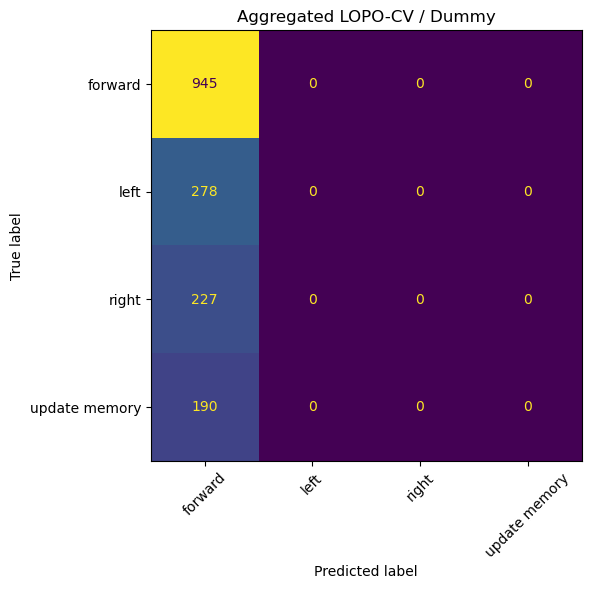

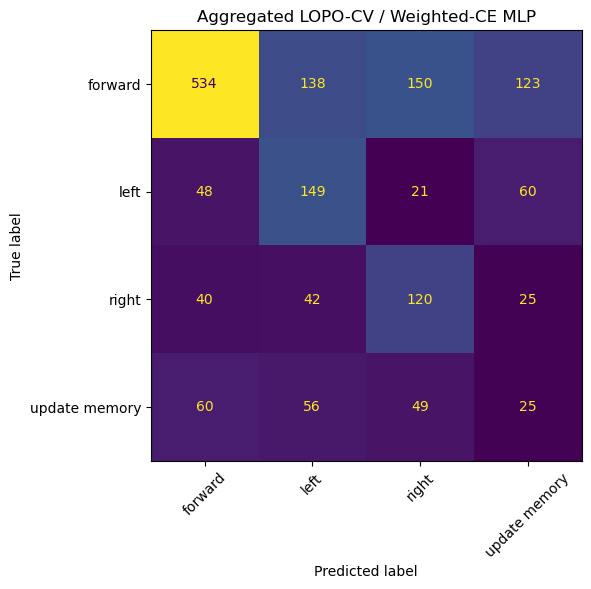

In [12]:
cm_dummy = confusion_matrix(y_true_all, y_pred_dummy_all, labels=np.arange(len(class_names)))
cm_mlp = confusion_matrix(y_true_all, y_pred_mlp_all, labels=np.arange(len(class_names)))

fig, ax = plt.subplots(figsize=(6, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_dummy, display_labels=class_names)
disp.plot(ax=ax, xticks_rotation=45, colorbar=False)
ax.set_title("Aggregated LOPO-CV / Dummy")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(6, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_mlp, display_labels=class_names)
disp.plot(ax=ax, xticks_rotation=45, colorbar=False)
ax.set_title("Aggregated LOPO-CV / Weighted-CE MLP")
plt.tight_layout()
plt.show()


## 12. Fold-wise plots


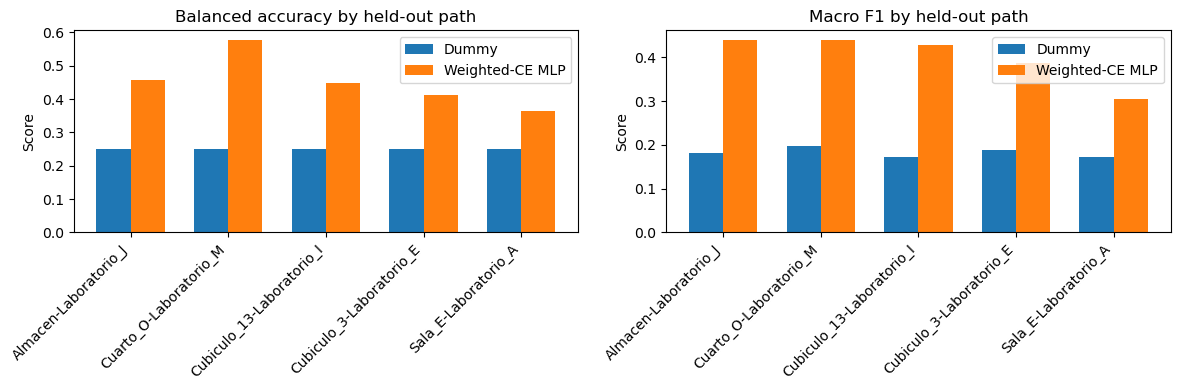

In [14]:
plot_df = fold_results_df[[
    "test_path",
    "dummy_balanced_accuracy",
    "mlp_balanced_accuracy",
    "dummy_macro_f1",
    "mlp_macro_f1",
]].copy()

plot_df = plot_df.sort_values("test_path").reset_index(drop=True)

x = np.arange(len(plot_df))
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# --- Balanced accuracy ---
axes[0].bar(
    x - width/2,
    plot_df["dummy_balanced_accuracy"].to_numpy(),
    width=width,
    label="Dummy"
)
axes[0].bar(
    x + width/2,
    plot_df["mlp_balanced_accuracy"].to_numpy(),
    width=width,
    label="Weighted-CE MLP"
)
axes[0].set_title("Balanced accuracy by held-out path")
axes[0].set_ylabel("Score")
axes[0].set_xticks(x)
axes[0].set_xticklabels(plot_df["test_path"], rotation=45, ha="right")
axes[0].legend()

# --- Macro F1 ---
axes[1].bar(
    x - width/2,
    plot_df["dummy_macro_f1"].to_numpy(),
    width=width,
    label="Dummy"
)
axes[1].bar(
    x + width/2,
    plot_df["mlp_macro_f1"].to_numpy(),
    width=width,
    label="Weighted-CE MLP"
)
axes[1].set_title("Macro F1 by held-out path")
axes[1].set_ylabel("Score")
axes[1].set_xticks(x)
axes[1].set_xticklabels(plot_df["test_path"], rotation=45, ha="right")
axes[1].legend()

plt.tight_layout()
plt.savefig(OUTPUT_ROOT / "foldwise_dummy_vs_mlp_metrics.png", dpi=200, bbox_inches="tight")
plt.show()

## 13. Training-history inspection


,epoch,train_loss,val_loss,val_bal_acc,fold,test_path,val_path
0,1,1.378965,1.336788,0.379372,0,Almacen-Laboratorio_J,Cuarto_O-Laboratorio_M
1,2,1.318638,1.329803,0.499765,0,Almacen-Laboratorio_J,Cuarto_O-Laboratorio_M
2,3,1.276248,1.289910,0.519502,0,Almacen-Laboratorio_J,Cuarto_O-Laboratorio_M
3,4,1.237928,1.267844,0.507736,0,Almacen-Laboratorio_J,Cuarto_O-Laboratorio_M
4,5,1.204338,1.239500,0.499513,0,Almacen-Laboratorio_J,Cuarto_O-Laboratorio_M


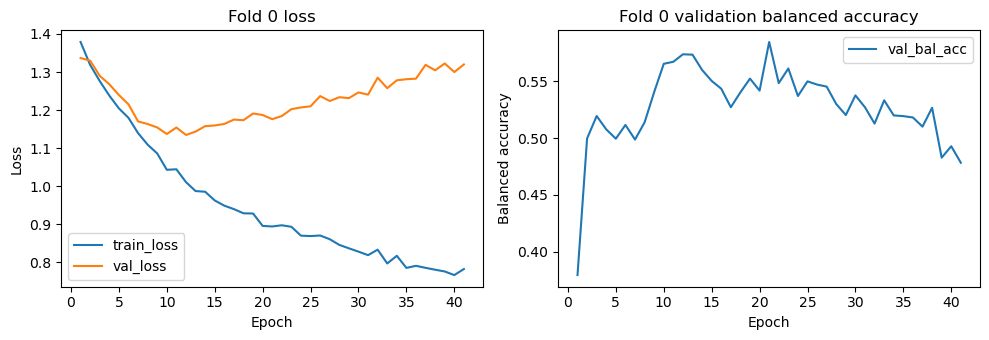

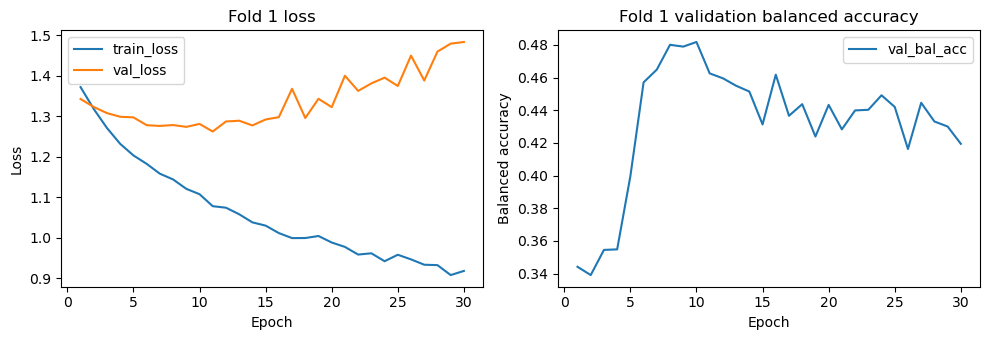

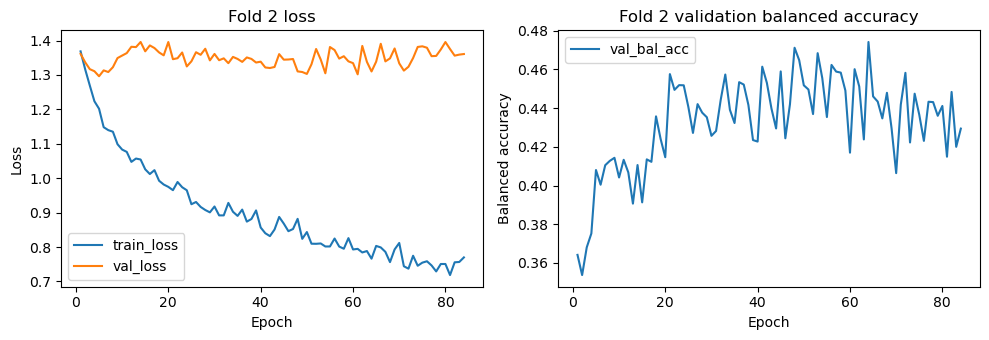

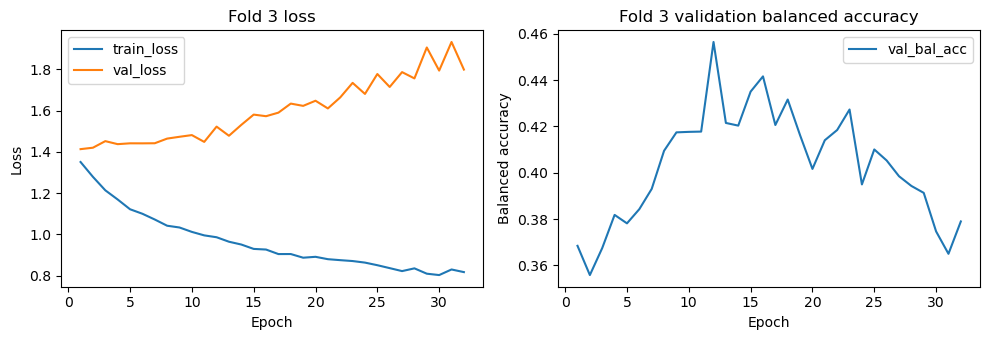

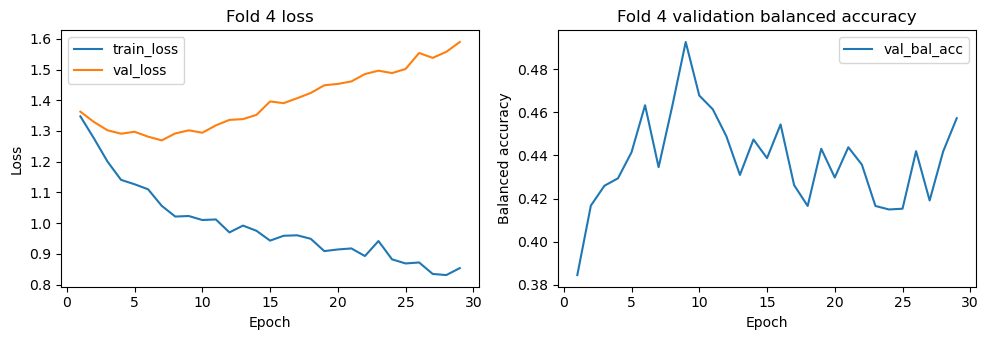

In [16]:
display(history_df.head())

for fold_id in sorted(history_df["fold"].unique().tolist()):
    h = history_df[history_df["fold"] == fold_id].copy().sort_values("epoch")

    epoch = h["epoch"].to_numpy()
    train_loss = h["train_loss"].to_numpy()
    val_loss = h["val_loss"].to_numpy()
    val_bal_acc = h["val_bal_acc"].to_numpy()

    fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))

    axes[0].plot(epoch, train_loss, label="train_loss")
    axes[0].plot(epoch, val_loss, label="val_loss")
    axes[0].set_title(f"Fold {fold_id} loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()

    axes[1].plot(epoch, val_bal_acc, label="val_bal_acc")
    axes[1].set_title(f"Fold {fold_id} validation balanced accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Balanced accuracy")
    axes[1].legend()

    plt.tight_layout()
    plt.show()

## 14. Per-class cross-validated metrics


In [17]:
display(per_class_cv_df)

per_class_summary = (
    per_class_cv_df.groupby("class_name")[["precision", "recall", "f1", "support"]]
    .agg({
        "precision": ["mean", "std"],
        "recall": ["mean", "std"],
        "f1": ["mean", "std"],
        "support": ["mean", "sum"],
    })
)
display(per_class_summary)
per_class_summary.to_csv(OUTPUT_ROOT / "per_class_summary.csv")


,class_name,precision,recall,f1,support,fold,test_path
0,forward,0.777273,0.581633,0.665370,294,0,Almacen-Laboratorio_J
1,left,0.363636,0.578947,0.446701,76,0,Almacen-Laboratorio_J
2,right,0.492754,0.447368,0.468966,76,0,Almacen-Laboratorio_J
3,update memory,0.148148,0.222222,0.177778,72,0,Almacen-Laboratorio_J
4,forward,0.873950,0.684211,0.767528,152,1,Cuarto_O-Laboratorio_M
5,left,0.349206,0.814815,0.488889,27,1,Cuarto_O-Laboratorio_M
6,right,0.361702,0.809524,0.500000,21,1,Cuarto_O-Laboratorio_M
7,update memory,0.000000,0.000000,0.000000,31,1,Cuarto_O-Laboratorio_M
8,forward,0.744681,0.614035,0.673077,171,2,Cubiculo_13-Laboratorio_I
9,left,0.515152,0.409639,0.456376,83,2,Cubiculo_13-Laboratorio_I


precision              recall                  f1            \
                   mean       std      mean       std      mean       std   
class_name                                                                  
forward        0.770232  0.085227  0.550927  0.134708  0.638756  0.122978   
left           0.392023  0.070605  0.574526  0.148833  0.452192  0.026226   
right          0.363335  0.099471  0.579747  0.167001  0.432852  0.086303   
update memory  0.060741  0.064395  0.101944  0.103169  0.075928  0.078890   

              support       
                 mean  sum  
class_name                  
forward         189.0  945  
left             55.6  278  
right            45.4  227  
update memory    38.0  190

## 15. Error inspection on cross-validated predictions


In [18]:
cv_predictions_df["is_correct_dummy"] = cv_predictions_df["y_true_enc"] == cv_predictions_df["y_pred_dummy_enc"]
cv_predictions_df["is_correct_mlp"] = cv_predictions_df["y_true_enc"] == cv_predictions_df["y_pred_mlp_enc"]

wrong_mlp_df = cv_predictions_df.loc[~cv_predictions_df["is_correct_mlp"]].copy()
print("Wrong MLP predictions:", len(wrong_mlp_df))

cols = [
    PATH_COLUMN,
    "current_rgb_filename",
    "key_rgb_filename",
    "y_true",
    "y_pred_mlp",
    "sim",
    "rmse",
    "x", "y", "z",
]
cols = [c for c in cols if c in wrong_mlp_df.columns]
display(wrong_mlp_df[cols].head(30))


Wrong MLP predictions: 812


,path_name,current_rgb_filename,key_rgb_filename,y_true,y_pred_mlp,sim,rmse,x,y,z
2,Almacen-Laboratorio_J,rgb_0038.png,rgb_0013.png,forward,update memory,0.773076,1.017799,0.350364,-0.180706,-1.474778
3,Almacen-Laboratorio_J,rgb_0039.png,rgb_0013.png,forward,update memory,0.772637,0.807778,0.155365,0.044004,-1.623744
7,Almacen-Laboratorio_J,rgb_0043.png,rgb_0013.png,forward,update memory,0.773135,1.278099,-0.210713,-0.026239,-1.509806
8,Almacen-Laboratorio_J,rgb_0044.png,rgb_0013.png,forward,update memory,0.764047,0.985558,0.193793,0.116255,-1.199742
9,Almacen-Laboratorio_J,rgb_0045.png,rgb_0013.png,forward,update memory,0.757412,1.118390,-0.362915,0.429524,-1.487594
10,Almacen-Laboratorio_J,rgb_0057.png,rgb_0013.png,left,update memory,0.753971,1.486044,-0.190724,0.395663,-1.273562
11,Almacen-Laboratorio_J,rgb_0058.png,rgb_0013.png,left,update memory,0.753179,1.295409,0.005060,0.205188,-1.099534
12,Almacen-Laboratorio_J,rgb_0059.png,rgb_0013.png,left,update memory,0.755216,1.319235,0.002666,0.195834,-1.108726
16,Almacen-Laboratorio_J,rgb_0072.png,rgb_0013.png,forward,update memory,0.738619,1.093249,-0.365215,0.314254,-1.120356
17,Almacen-Laboratorio_J,rgb_0073.png,rgb_0013.png,forward,update memory,0.760685,1.287296,-0.267126,0.323089,-1.041813


## 16. Final interpretation guide

What to look for:

1. **Mean and std across folds**
   - low mean + high std => unstable generalization across paths
2. **Per-held-out-path metrics**
   - one or two catastrophic folds imply strong path bias
3. **Per-class recall**
   - especially `left`, `right`, and `update memory`
4. **Dummy vs weighted-CE MLP**
   - if weighted-CE barely beats dummy on balanced accuracy / macro F1, the feature set is probably the bottleneck
5. **Per-path class distribution**
   - some folds may be intrinsically harder because a held-out path has a very different action distribution

Brutally honest interpretation rule:

- If the MLP only improves weighted F1 or raw accuracy but not balanced accuracy / macro F1, it is still mostly exploiting majority-class structure.
- If results vary strongly by held-out path, the main problem is probably path shift rather than only class imbalance.
- If weighted cross-entropy still fails badly on minority classes, you should inspect the feature representation itself, not only the classifier.


In [19]:
# Save one final deployable weighted-CE MLP trained on all available data
# using a small validation split taken from the full dataset.
#
# Outputs:
# - final_scaler.joblib
# - final_label_encoder.joblib
# - final_weighted_ce_mlp.pt
# - final_model_metadata.json
#
# Paste this near the bottom of the notebook, after all helper classes/functions
# are already defined (WeightedMLP, train_torch_mlp, etc.).

from joblib import dump
from sklearn.model_selection import train_test_split

final_df = valid_df.dropna(subset=FEATURE_COLUMNS + [PATH_COLUMN, LABEL_COLUMN]).copy()

X_all = final_df[FEATURE_COLUMNS].astype(float).to_numpy()
y_all = label_encoder.transform(final_df[LABEL_COLUMN].to_numpy())

# Stratified split only for early stopping; this is not for final evaluation.
X_train_full, X_val_full, y_train_full, y_val_full = train_test_split(
    X_all,
    y_all,
    test_size=0.15,
    random_state=RANDOM_STATE,
    stratify=y_all,
)

final_scaler = StandardScaler()
X_train_full_sc = final_scaler.fit_transform(X_train_full)
X_val_full_sc = final_scaler.transform(X_val_full)

set_seed(RANDOM_STATE + 999)

final_model, final_history_df, final_class_weights, final_best_epoch, final_best_val_bal_acc = train_torch_mlp(
    X_train_full_sc,
    y_train_full,
    X_val_full_sc,
    y_val_full,
    n_classes=len(class_names),
    hidden_dims=tuple(HIDDEN_DIMS),
    dropout=DROPOUT,
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
    batch_size=BATCH_SIZE,
    max_epochs=MAX_EPOCHS,
    patience=EARLY_STOPPING_PATIENCE,
    device=DEVICE,
)

# Save artifacts
dump(final_scaler, OUTPUT_ROOT / "final_scaler.joblib")
dump(label_encoder, OUTPUT_ROOT / "final_label_encoder.joblib")

torch.save(
    {
        "model_state_dict": final_model.state_dict(),
        "input_dim": int(X_train_full_sc.shape[1]),
        "num_classes": int(len(class_names)),
        "hidden_dims": list(HIDDEN_DIMS),
        "dropout": float(DROPOUT),
        "class_names": list(class_names),
        "feature_columns": list(FEATURE_COLUMNS),
        "device_trained": DEVICE,
    },
    OUTPUT_ROOT / "final_weighted_ce_mlp.pt"
)

final_metadata = {
    "feature_columns": list(FEATURE_COLUMNS),
    "class_names": list(class_names),
    "hidden_dims": list(HIDDEN_DIMS),
    "dropout": float(DROPOUT),
    "batch_size": int(BATCH_SIZE),
    "max_epochs": int(MAX_EPOCHS),
    "learning_rate": float(LEARNING_RATE),
    "weight_decay": float(WEIGHT_DECAY),
    "early_stopping_patience": int(EARLY_STOPPING_PATIENCE),
    "random_state": int(RANDOM_STATE),
    "device": DEVICE,
    "n_total": int(len(final_df)),
    "n_train_for_fit": int(len(X_train_full)),
    "n_val_for_early_stopping": int(len(X_val_full)),
    "best_epoch": int(final_best_epoch),
    "best_val_bal_acc": float(final_best_val_bal_acc),
    "class_weights": [float(x) for x in final_class_weights],
    "notes": "Final deployable model trained on all available rows with an internal validation split used only for early stopping.",
}

with open(OUTPUT_ROOT / "final_model_metadata.json", "w", encoding="utf-8") as f:
    json.dump(final_metadata, f, indent=2)

final_history_df.to_csv(OUTPUT_ROOT / "final_training_history.csv", index=False)

print("Saved:")
print(" -", OUTPUT_ROOT / "final_scaler.joblib")
print(" -", OUTPUT_ROOT / "final_label_encoder.joblib")
print(" -", OUTPUT_ROOT / "final_weighted_ce_mlp.pt")
print(" -", OUTPUT_ROOT / "final_model_metadata.json")
print(" -", OUTPUT_ROOT / "final_training_history.csv")
print("\nBest epoch:", final_best_epoch)
print("Best val balanced accuracy:", round(final_best_val_bal_acc, 4))

Saved:
 - /home/rodriguez/Documents/GitHub/rpi_nav/notebook_outputs/real_nav_lopo_weighted_ce/final_scaler.joblib
 - /home/rodriguez/Documents/GitHub/rpi_nav/notebook_outputs/real_nav_lopo_weighted_ce/final_label_encoder.joblib
 - /home/rodriguez/Documents/GitHub/rpi_nav/notebook_outputs/real_nav_lopo_weighted_ce/final_weighted_ce_mlp.pt
 - /home/rodriguez/Documents/GitHub/rpi_nav/notebook_outputs/real_nav_lopo_weighted_ce/final_model_metadata.json
 - /home/rodriguez/Documents/GitHub/rpi_nav/notebook_outputs/real_nav_lopo_weighted_ce/final_training_history.csv

Best epoch: 42
Best val balanced accuracy: 0.6451
